In [4]:
# dataset: letterdata.csv
# location: https://mitu.co.in/dataset

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
df = pd.read_csv('letterdata.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [14]:
df.shape

(20000, 17)

In [16]:
df.columns

Index(['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar',
       'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey',
       'yedge', 'yedgex'],
      dtype='object')

In [18]:
df.isnull().sum()

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

In [20]:
x = df.drop('letter', axis = 1)
y = df['letter']

In [22]:
y.value_counts()

letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

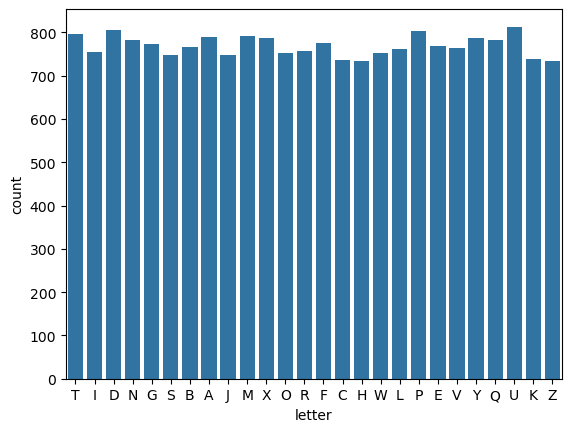

In [24]:
sns.countplot(x = y);

#### cross validation

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   random_state=0,
                                                   test_size= 0.20)

In [29]:
x_train.shape

(16000, 16)

In [31]:
y_train.shape

(16000,)

#### build the model

In [34]:
from sklearn.svm import SVC

In [89]:
svc = SVC(kernel= 'sigmoid')

In [91]:
svc.fit(x_train, y_train)

SVC(kernel='sigmoid')

#### evaluate 

In [93]:
y_pred = svc.predict(x_test)

In [94]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

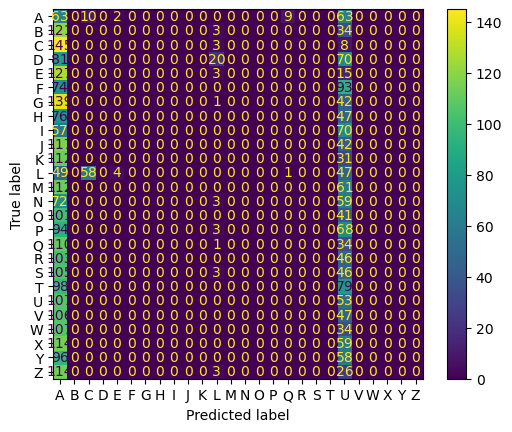

In [95]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.02      0.43      0.05       147
           B       0.00      0.00      0.00       158
           C       0.00      0.00      0.00       156
           D       0.00      0.00      0.00       171
           E       0.00      0.00      0.00       145
           F       0.00      0.00      0.00       167
           G       0.00      0.00      0.00       182
           H       0.00      0.00      0.00       123
           I       0.00      0.00      0.00       127
           J       0.00      0.00      0.00       159
           K       0.00      0.00      0.00       143
           L       0.00      0.00      0.00       159
           M       0.00      0.00      0.00       173
           N       0.00      0.00      0.00       134
           O       0.00      0.00      0.00       142
           P       0.00      0.00      0.00       165
           Q       0.00      0.00      0.00       145
           R       0.00    

/home/aditya/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aditya/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aditya/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [97]:
accuracy_score(y_test, y_pred)

0.029

In [104]:
# linear = 0.8655
# poly = 0.95425
# rbf = 0.9335
# sigmoid = 0.029

In [112]:
new1 = [[6, 5, 7, 8, 8, 13, 0, 6, 6, 4, 5, 3, 4, 8, 1, 7]]

In [114]:
svc.predict(new1)

/home/aditya/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['U'], dtype=object)